# Benchmark Analysis\nCompare lookup and insert throughput for BTree, DynamicPGM, and LIPP across three datasets (fb, osmc, books).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

tasks = ['fb', 'osmc', 'books']
indexs = ['BTree', 'DynamicPGM', 'LIPP']

# Load all result CSVs
data = {}
for task in tasks:
    name = f"{task}_100M_public_uint64"
    data[task] = {
        'lookup_only': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.000000i_results_table.csv"),
        'insert_lookup': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.500000i_0m_results_table.csv"),
        'mix_10': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.100000i_0m_mix_results_table.csv"),
        'mix_90': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.900000i_0m_mix_results_table.csv"),
    }
print("Loaded all results.")

Loaded all results.


In [2]:
def best_throughput(df, index_name, cols):
    """Get the best average throughput for a given index (best across search methods)."""
    rows = df[df['index_name'] == index_name]
    if rows.empty:
        return 0
    return rows[cols].mean(axis=1).max()

# Build throughput tables
lookuponly = pd.DataFrame({
    idx: {task: best_throughput(data[task]['lookup_only'], idx,
          ['lookup_throughput_mops1', 'lookup_throughput_mops2', 'lookup_throughput_mops3'])
          for task in tasks}
    for idx in indexs
})

insert_tp = pd.DataFrame({
    idx: {task: best_throughput(data[task]['insert_lookup'], idx,
          ['insert_throughput_mops1', 'insert_throughput_mops2', 'insert_throughput_mops3'])
          for task in tasks}
    for idx in indexs
})

lookup_after_insert = pd.DataFrame({
    idx: {task: best_throughput(data[task]['insert_lookup'], idx,
          ['lookup_throughput_mops1', 'lookup_throughput_mops2', 'lookup_throughput_mops3'])
          for task in tasks}
    for idx in indexs
})

mix10 = pd.DataFrame({
    idx: {task: best_throughput(data[task]['mix_10'], idx,
          ['mixed_throughput_mops1', 'mixed_throughput_mops2', 'mixed_throughput_mops3'])
          for task in tasks}
    for idx in indexs
})

mix90 = pd.DataFrame({
    idx: {task: best_throughput(data[task]['mix_90'], idx,
          ['mixed_throughput_mops1', 'mixed_throughput_mops2', 'mixed_throughput_mops3'])
          for task in tasks}
    for idx in indexs
})

print("Throughput tables computed.")

Throughput tables computed.


## Lookup-only Throughput

          BTree  DynamicPGM        LIPP
fb     1.217800    1.656397  340.562000
osmc   1.679273    1.842620  363.410667
books  1.331873    1.879073  358.872333



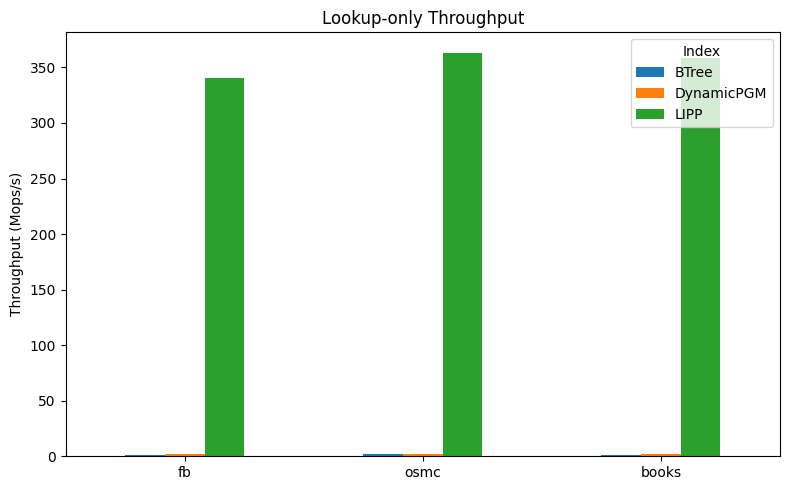

In [3]:
print(lookuponly.to_string())
print()

ax = lookuponly.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('Throughput (Mops/s)')
ax.set_title('Lookup-only Throughput')
ax.set_xticklabels(tasks, rotation=0)
ax.legend(title='Index')
plt.tight_layout()
plt.show()

## Insert Throughput (from 50% insert workload)

          BTree  DynamicPGM      LIPP
fb     0.822530    5.867797  2.242583
osmc   0.887347    5.073863  1.847047
books  0.888139    5.800243  3.007033



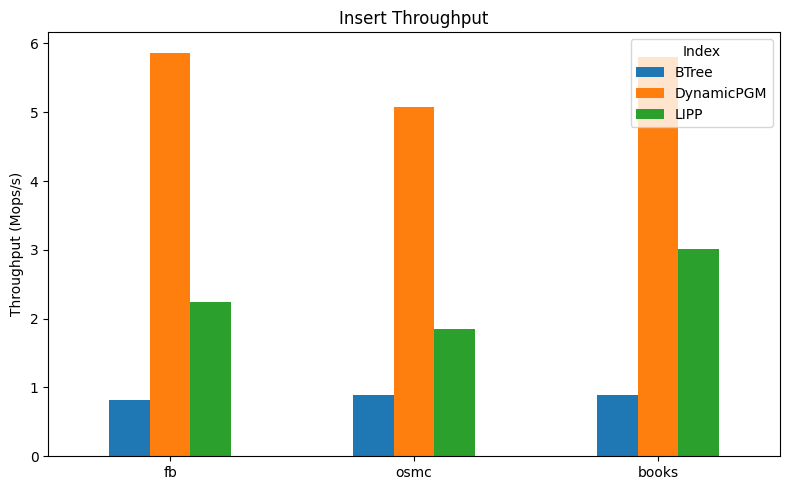

In [4]:
print(insert_tp.to_string())
print()

ax = insert_tp.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('Throughput (Mops/s)')
ax.set_title('Insert Throughput')
ax.set_xticklabels(tasks, rotation=0)
ax.legend(title='Index')
plt.tight_layout()
plt.show()

## Lookup Throughput after Inserts (from 50% insert workload)

          BTree  DynamicPGM        LIPP
fb     1.107017    0.369446  345.693333
osmc   1.522923    0.406684  363.285000
books  1.189530    0.455098  348.574333



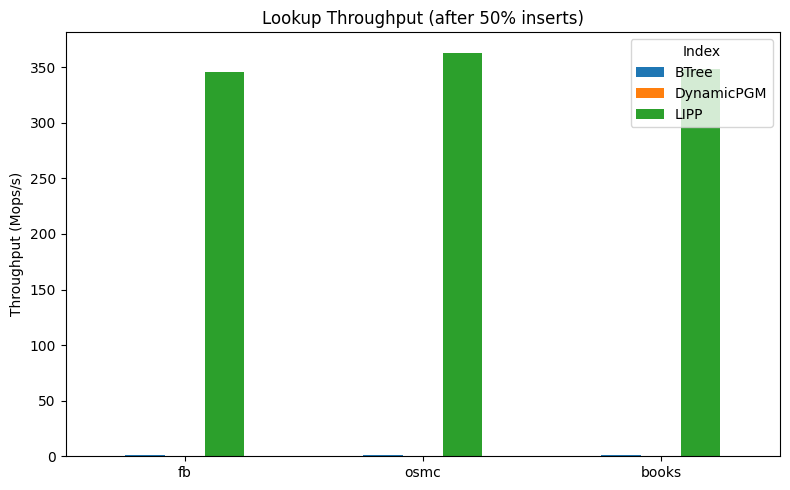

In [5]:
print(lookup_after_insert.to_string())
print()

ax = lookup_after_insert.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('Throughput (Mops/s)')
ax.set_title('Lookup Throughput (after 50% inserts)')
ax.set_xticklabels(tasks, rotation=0)
ax.legend(title='Index')
plt.tight_layout()
plt.show()

## Mixed Workload - 10% Insert Ratio

          BTree  DynamicPGM       LIPP
fb     1.071660    0.722031  17.234367
osmc   1.421507    0.877027  15.257367
books  1.177023    0.918318  23.652133



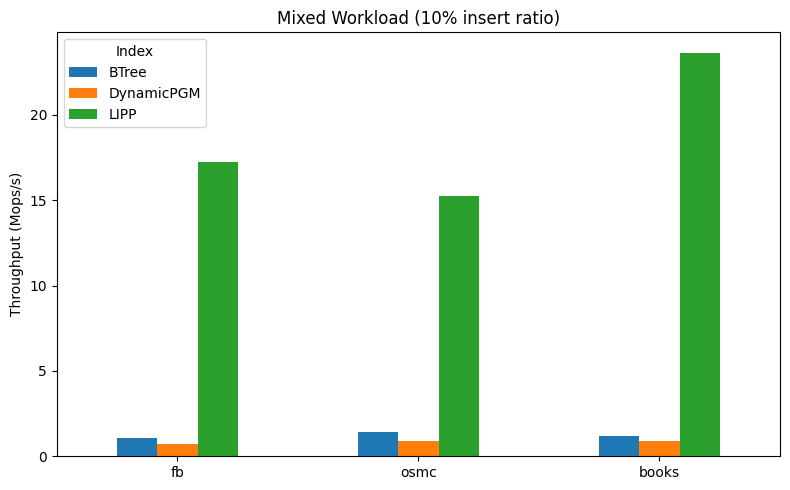

In [6]:
print(mix10.to_string())
print()

ax = mix10.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('Throughput (Mops/s)')
ax.set_title('Mixed Workload (10% insert ratio)')
ax.set_xticklabels(tasks, rotation=0)
ax.legend(title='Index')
plt.tight_layout()
plt.show()

## Mixed Workload - 90% Insert Ratio

          BTree  DynamicPGM      LIPP
fb     0.783167    2.377640  2.447227
osmc   0.884448    2.460737  2.030887
books  0.874615    2.801180  3.403873



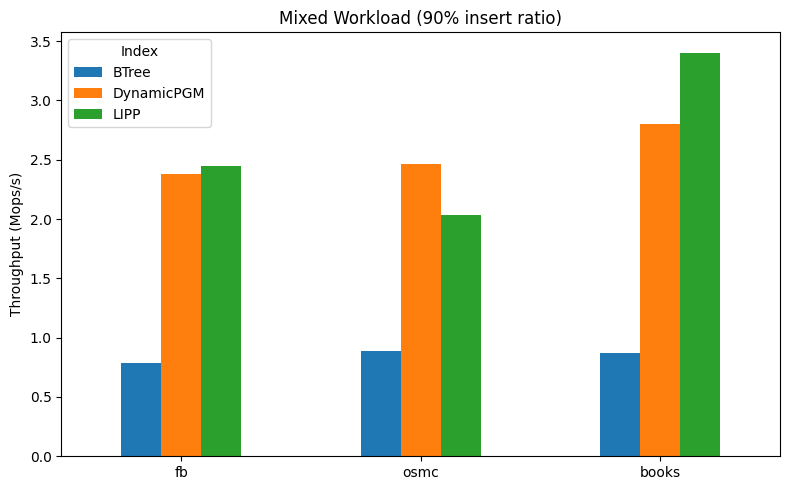

In [7]:
print(mix90.to_string())
print()

ax = mix90.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('Throughput (Mops/s)')
ax.set_title('Mixed Workload (90% insert ratio)')
ax.set_xticklabels(tasks, rotation=0)
ax.legend(title='Index')
plt.tight_layout()
plt.show()